# DBNets2.0. Tutorial: application to an actual observation
In this jupyter notebook the tool is applied to MWC480 (data from the ALMA archive)

1. Install DBNets following the instructions provided on the github repo.

2. Import the DBNets2 library and initialize the models. Provide the paths of the trained CNN and Normalizing Flows.

In [1]:
from DBNets import DBNets2
import matplotlib.pyplot as plt

dbnets = DBNets2()

3. Collect the data needed on the protoplanetary disc under exam
    - fits file with the continuum observation in ALMA band 6 or 7
    - centre of the disc in pixel coordinates
    - inclination
    - position angle
    - planet position (as an angle or as distance + physical separation)

![definition of inclination and position angle](inclandpa.png)

In [2]:
file_name = 'mwc480.fits'
centre = (1024, 1026)
inclination = 36
pa = 58
distance = 161
rp = 73
res_ba_arcsec = 0.15

IMPORTANT: DBNets requires as input the observation resolution in units relative to the assumed planet position. The following formula converts the beam size of semi-major axis in arcseconds to these code units.

In [3]:
#define the image resolution in the same code units used in the code
res_sigma = res_ba_arcsec/2.355*distance/rp

(np.float64(-0.5), np.float64(2047.5), np.float64(2047.5), np.float64(-0.5))

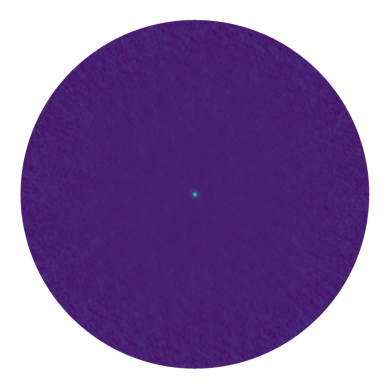

In [4]:
#you can check the image
from astropy.io import fits

hdu = fits.open(file_name)[0]
plt.imshow(hdu.data[0,0])
plt.axis('off')

4. use DBNets.preproc module to open and preprocess the fits file. This function opens the fits file, rescales and deprojects the disc to make the observation geometrically homogeneous with the synthetic observations used to train the ensemble. The following picture shows the data before and after.

![preprocessing](preprocess.png)

In [5]:
from DBNets import preproc as pp
deproj_image = pp.deproject_image(file_name, distance, inclination, pa, centre, rp)

this is the image obtained

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

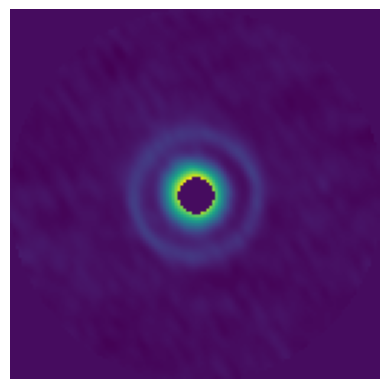

In [6]:
import matplotlib.pyplot as plt
plt.imshow(deproj_image)
plt.axis('off')

5. run the inference sampling N points from the inferred posterior

In [7]:
samples, cs = dbnets(deproj_image, [res_sigma], nsamples=50000)

10181it [00:00, 14984.51it/s]                                                  
10100it [00:00, 17251.66it/s]                                                  
100%|███████████████████████████████████| 9849/9849 [00:00<00:00, 17646.27it/s]
10100it [00:00, 16886.81it/s]                                                  

loading all data and parameters
Sample 10 estimates from the posteriror distribution
Interpolating 10 best estimates
Standardize data
FFT
done.
 Compute metric..
DONE!


The method returns `nsamples` samples from the inferred posterior.

These are returned in an array we the following shape: (ninputs, nsamples, 4).

__The last dimension corresponds to the 4 inferred properties in the following order: Alpha, AspectRatio, Stokes, Planet to Star mass ratio__.

The second output cs contains the confidence scores.

In [8]:
import numpy as np
np.median(np.nan_to_num(samples), axis=1)

array([[0.00057847, 0.08584075, 0.01704061, 0.00038588]])

You can plot these results, for example, using the function `utils.plot_corner`.

In [9]:
from DBNets import utils

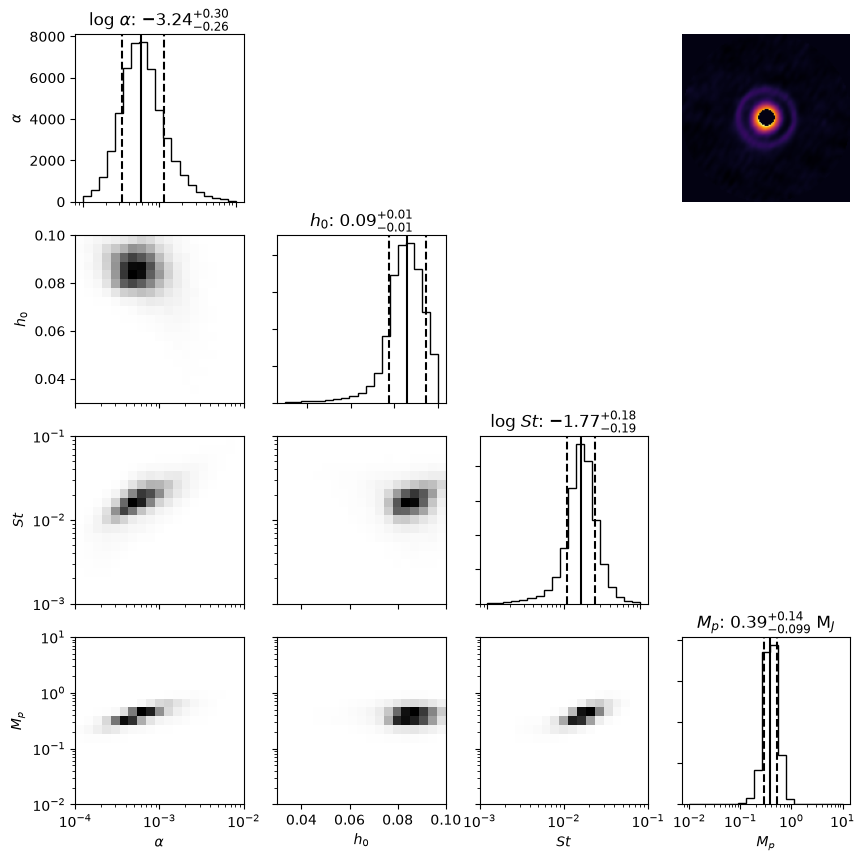

In [10]:
utils.plot_corner(samples[0],name='mwc480', savepath='corner.pdf', image = deproj_image, starmass=1e3)

### Check the difference between the summary statistics and the samples from the normalizing flows

In [ ]:
summary_stat, _ = dbnets.loaded_models(deproj_image.reshape(128, 128, 1), res_sigma, return_preactivated=True)
summary_stat = utils.to_real(summary_stat, log=False)

In [ ]:
samples.shape

In [ ]:
# plot 4 histograms of the summary statistics and the samples for each parameter
from networkx import density
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()
lims = [(1e-4, 1e-2), (0.03, 0.1), (1e-3, 1e-1), (1e-5, 1e-2)]
bins = [np.logspace(np.log10(lims[i][0]), np.log10(lims[i][1]), 30) if i!=1 else np.linspace(lims[i][0], lims[i][1], 30) for i in range(4)]
params_labels = ['$\\alpha$', 'h', 'St', '$M_p$']
for i in range(4):
    axs[i].hist(summary_stat[:,i], bins=bins[i], density=True, label='Summary statistics')
    axs[i].hist(samples[0,:,i], bins=bins[i], alpha=0.5, density=True, label='Samples from DBNets')
    if i!=1:
        axs[i].set_xscale('log')
    axs[i].set_xlabel('')
    axs[i].legend()
    axs[i].set_xlabel(f'{params_labels[i]}',  fontsize=12)

# Confidence score

The confidence score returned with this inference is:

In [ ]:
print(f'Confidence score: {cs[0]:.2f}')

We will try to vissualize the interpolations of the training dataset which are used to compute the confidence score

In [ ]:
from DBNets import __confidence_score as cs_module

cs, interp_data = cs_module.get_cs(deproj_image.reshape(1,128,128,1), samples, nsamples=9, mask_rin=0.5, mask_rout=3.0,get_interp_data=True)

In [ ]:
# for comparison, reshape the input data as done for computing the confidence score and normalize it
polar_input_data = cs_module.regrid(deproj_image.reshape(-1,128*128))
polar_input_data = (polar_input_data-polar_input_data.mean(axis=(1,2)).reshape(1,-1,1,1))/polar_input_data.std(axis=(1,2)).reshape(1,-1,1,1)

In [ ]:
# plots
fig, axs = plt.subplots(2,5, figsize=(15,6))
plot = axs[0,0].imshow(polar_input_data[0,0])
axs[0,0].set_title('Input image')
axs[0,0].axis('off')
plt.colorbar(plot, ax=axs[0,0], fraction=0.046, pad=0.04)

for i in range(1,10):
    plot = axs[(i)//5,(i)%5].imshow(interp_data[i-1,0])
    axs[(i)//5,(i)%5].set_title(f'Interpolated image {i}')
    axs[(i)//5,(i)%5].axis('off')
    plt.colorbar(plot, ax=axs[i//5,i%5], fraction=0.046, pad=0.04)
    
#add colorbars
plt.tight_layout()

In [ ]:
#import a list of color from gray colormap
from cv2 import line


colors = plt.cm.gray(np.linspace(0, 1, 10))

plt.plot(polar_input_data[0,0].mean(axis=0), label='Input image', linewidth=5, zorder=1)

for i in range(9):
    plt.plot(interp_data[i,0].mean(axis=0), label=f'Interpolated image {i+1}', color=colors[i], alpha=0.7, linewidth=5, zorder=0)

plt.legend()
plt.xlabel('Radial distance (pixels)')
plt.ylabel('Standardized intensity')

Try now if the confidence score can detect out of distribution data.

Let's hide a cat in the DSHARP data.

In [ ]:
import os
images = []
# for filename in os.listdir('some_disks'):
#     images.append(np.load(f'some_disks/{filename}'))
# images = np.array(images)

#let's add the cat
from PIL import Image
cat_image = np.array(Image.open('cat.jpeg').convert('L').resize((128,128)))
#preprocess the cat image to match the input of the network
import astropy.units as u
pxscale = 8*u.arcsec/(128*u.pixel)
cat_image = pp.deproject_image(cat_image, 1, 0,0, (64,64), 1, pxscale=pxscale.to(u.deg/u.pixel).value)

# add cat image to the list of images and shuffle the list
# images = np.concatenate((images, cat_image.reshape(1,128,128)), axis=0)
images = cat_image.reshape(1,128,128)
np.random.shuffle(images)   
images.shape

In [ ]:
#plot the images
fig, axs = plt.subplots(2,3, figsize=(15,6))
for i in range(6):
    plot = axs[i//3,i%3].imshow(images[i])
    axs[i//3,i%3].set_title(f'Image {i+1}')
    axs[i//3,i%3].axis('off')

In [ ]:
# use DBNets2 to compute the confidence score for each image and plot the scores
scores = []
samples, cscores = dbnets(images, np.ones(6)*0.01, nsamples=1000)

In [ ]:
plt.ylabel('Confidence Score')
plt.xlabel('Image Number')
#green bar the cs>0.6 and red bar cs<0.6
for i in range(6):
    if cscores[i] > 0.6:
        plt.bar(i+1, cscores[i], color='green')
    else:
        plt.bar(i+1, cscores[i], color='red')
        
plt.axhline(0.6, color='black', linestyle='--', label='Threshold')
plt.legend()

# Estimating as a function of $R_p$

When unsure where the planet might be, e.g. for cavities, DBNets2.0 can be called multiple times showing the degeneracy of the inferred properties with $R_p$

In [ ]:
#We are going to use the cavity in the J1604 exoAlma continuum image
#fits file was downloaded from: https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/6HWZWA

fitsname = f"j1604.fits"
hdu = fits.open(fitsname)
data = hdu[0].data[0,0]
cdelta = hdu[0].header['CDELT1']
cx = data.shape[0]//2  -74.82/(cdelta*3600000)
cy = data.shape[1]//2  + 16.67/(cdelta*3600000)

# geometrical parameters of the disk are from Curone+2025
distance = 145
inclination = 8.72
pa = 123.24
center = (605, 599)

In [ ]:
from tqdm import tqdm

filename = 'j1604.fits'

resolution = []

rp_limits = (10, 82) #au
nsamples = 10

deproj_images = []

for r in tqdm(np.linspace(*rp_limits, nsamples), desc='deprojection'):
    deproj_images.append(pp.deproject_image(filename,
                                                  distance,
                                                  inclination,
                                                  pa,
                                                  center,
                                                  r))
    resolution.append(utils.beam_to_cu(0.095,distance,r))

In [ ]:
all_samples, all_cscores = dbnets(np.array(deproj_images), np.array(resolution), nsamples=1000)

In [ ]:
r = np.linspace(*rp_limits, 10)
r_ext = r.reshape(-1,1)*np.ones(all_samples.shape[:-1])
fig, axs = plt.subplots(1,4, figsize=(12,3))

print(all_samples.shape)
axs[0].hist2d(r_ext.flatten(), all_samples[:, :, 3].flatten(), bins=(np.linspace(*rp_limits,10), np.logspace(-5,-1,100)), label='Major axis', cmap='binary', zorder=-1)
axs[0].plot(r, np.median(all_samples[:, :, 3], axis=1), color='orange' )
axs[0].plot(r, np.percentile(all_samples[:, :, 3], 16, axis=1), color='orange', linestyle='--')
axs[0].plot(r, np.percentile(all_samples[:, :, 3], 84, axis=1), color='orange', linestyle='--')
axs[0].set_xlabel('$R_p$ [au]', fontsize=12)
axs[0].set_ylabel('Planet-star mass ratio', fontsize=12)
axs[0].set_yscale('log')
axs[0].set_ylim(1e-5, 1e-2)
axs[0].set_rasterization_zorder(0)
axs[0].set_title(f'J1604', loc='right', fontsize=12)

#plt.axvline(rp_limits[i][-1]*2/3, color='orange', linestyle='dashed')

axs[1].hist2d(r_ext.flatten(), all_samples[:, :, 0].flatten(), bins=(np.linspace(*rp_limits,10), np.logspace(-4,-2,100)), label='Major axis', cmap='binary', zorder=-1)
axs[1].plot(r, np.median(all_samples[:, :, 0], axis=1), color='orange' )
axs[1].plot(r, np.percentile(all_samples[:, :, 0], 16, axis=1), color='orange', linestyle='--')
axs[1].plot(r, np.percentile(all_samples[:, :, 0], 84, axis=1), color='orange', linestyle='--')
axs[1].set_xlabel('$R_p$ [au]', fontsize=12)
axs[1].set_ylabel('$\\alpha$', fontsize=12)
axs[1].set_yscale('log')
axs[1].set_ylim(1e-4, 1e-2)
axs[1].set_rasterization_zorder(0)
axs[1].set_title(f'J1604', loc='right', fontsize=12)

axs[2].hist2d(r_ext.flatten(), all_samples[:, :, 1].flatten(), bins=(np.linspace(*rp_limits,10), np.linspace(0.03,0.1,100)), label='Major axis', cmap='binary', zorder=-1)
axs[2].plot(r, np.median(all_samples[:, :, 1], axis=1), color='orange' )
axs[2].plot(r, np.percentile(all_samples[:, :, 1], 16, axis=1), color='orange', linestyle='--')
axs[2].plot(r, np.percentile(all_samples[:, :, 1], 84, axis=1), color='orange', linestyle='--')
axs[2].set_xlabel('$R_p$ [au]', fontsize=12)
axs[2].set_ylabel('$h$', fontsize=12)
#plt.yscale('log')
axs[2].set_ylim(0.03, 0.1)
axs[2].set_rasterization_zorder(0)
axs[2].set_title(f'J1604', loc='right', fontsize=12)

axs[3].hist2d(r_ext.flatten(), all_samples[:, :, 2].flatten(), bins=(np.linspace(*rp_limits,10), np.logspace(-3,-1,100)), label='Major axis', cmap='binary', zorder=-1)
axs[3].plot(r, np.median(all_samples[:, :, 2], axis=1), color='orange' )
axs[3].plot(r, np.percentile(all_samples[:, :, 2], 16, axis=1), color='orange', linestyle='--')
axs[3].plot(r, np.percentile(all_samples[:, :, 2], 84, axis=1), color='orange', linestyle='--')
axs[3].set_xlabel('$R_p$ [au]', fontsize=12)
axs[3].set_ylabel('St', fontsize=12)
axs[3].set_yscale('log')
axs[3].set_ylim(1e-3, 1e-1)
axs[3].set_rasterization_zorder(0)
axs[3].set_title(f'J1604', loc='right', fontsize=12)

for j in range(4):
    ax2 = axs[j].twinx()  # replace j with 0, 1, 2, or 3 depending on the subplot
    ax2.plot(r, all_cscores, color='red', lw=2, zorder=5, alpha=0.4)
    ax2.set_ylim(0, 1)
    if j==3:
        ax2.set_ylabel('CS', color='red', fontsize=10)
        ax2.tick_params(axis='y', labelcolor='red')
    else:
        ax2.set_yticks([0.6], labels=[''])

plt.tight_layout()


In [ ]:
# Note how the CS goes above 0.6 starting from the third R_p.
# Check deproj_images[0], deproj_images[1] and deproj_images[2] see why

plt.imshow(deproj_images[2])
plt.axis('off')